In [4]:
# ====================== IMPORTS ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

from geopy.distance import geodesic

import kagglehub
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# ====================== LOAD DATA ======================
path = kagglehub.dataset_download("crailtap/taxi-trajectory")
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "train.csv"))
df = df.sample(50000, random_state=42).reset_index(drop=True)

print("Dataset Shape:", df.shape)

In [ ]:
# ====================== CLEANING ======================
df = df[df['POLYLINE'] != '[]'].copy()
df['POLYLINE'] = df['POLYLINE'].apply(ast.literal_eval)


In [ ]:
# ====================== FEATURE ENGINEERING ======================
def extract_features(polyline):
    if len(polyline) < 2:
        return [0]*8

    distances = []
    speeds = []

    time_gap = 15

    for i in range(1, len(polyline)):
        p1 = polyline[i-1]
        p2 = polyline[i]

        dist = geodesic((p1[1], p1[0]), (p2[1], p2[0])).meters
        distances.append(dist)
        speeds.append(dist / time_gap)

    distances = np.array(distances)
    speeds = np.array(speeds)

    accel = np.diff(speeds) if len(speeds) > 1 else [0]

    return [
        distances.sum(),
        distances.mean(),
        distances.max(),
        speeds.mean(),
        speeds.max(),
        np.mean(np.abs(accel)),
        np.sum(distances < 2),
        len(polyline)
    ]


features = df['POLYLINE'].apply(extract_features)

df[['total_dist','avg_step_dist','max_step_dist',
    'avg_speed','max_speed','avg_accel','stops','num_points']] = \
    pd.DataFrame(features.tolist(), index=df.index)


In [ ]:
# ====================== REMOVE BAD DATA ======================
df = df[(df['num_points'] > 2) & (df['total_dist'] > 0)]

df = df[df['max_speed'] < 40]
df = df[df['avg_accel'] < 10]


In [ ]:
# remove idle trips (important)
df = df[df['avg_speed'] > 3]

df = df.reset_index(drop=True)

print("After cleaning:", df.shape)

In [ ]:
# ====================== BEHAVIOR FEATURES ======================
df['speed_variation'] = df['max_speed'] - df['avg_speed']
df['speed_consistency'] = df['avg_speed'] / (df['max_speed'] + 1e-5)
df['stop_rate'] = df['stops'] / (df['num_points'] + 1e-5)

In [ ]:
# ====================== TIME FEATURES ======================
df['datetime'] = pd.to_datetime(df['TIMESTAMP'], unit='s')
df['hour'] = df['datetime'].dt.hour

In [ ]:
# ====================== MODEL FEATURES ======================
model_features = [
    'avg_speed','max_speed','avg_accel',
    'speed_variation','speed_consistency',
    'stop_rate','hour'
]

X = df[model_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# ====================== MODEL 1: ISOLATION FOREST ======================
iso = IsolationForest(n_estimators=150, contamination=0.05, random_state=42)

df['iso_pred'] = iso.fit_predict(X_scaled)
df['iso_score_raw'] = iso.decision_function(X_scaled)
df['iso_risky'] = (df['iso_pred'] == -1).astype(int)


In [ ]:
# ====================== MODEL 2: LOF ======================
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

df['lof_pred'] = lof.fit_predict(X_scaled)
df['lof_risky'] = (df['lof_pred'] == -1).astype(int)

In [ ]:

# ====================== AGREEMENT ======================
df['agreement'] = (df['iso_risky'] == df['lof_risky']).astype(int)
print("Agreement %:", df['agreement'].mean())


In [ ]:
# ====================== RISK SCORE ======================
# Convert iso score → positive risk
df['risk_score'] = -df['iso_score_raw']

# normalize
df['risk_score'] = (df['risk_score'] - df['risk_score'].min()) / \
                   (df['risk_score'].max() - df['risk_score'].min())

In [ ]:
# ====================== ADJUST RISK (REMOVE TRAFFIC BIAS) ======================
df['risk_adjusted'] = df['risk_score'] * (1 - df['stop_rate'])**2


In [ ]:
# ====================== FINAL LABEL ======================
df['is_risky'] = (df['risk_adjusted'] > 0.6).astype(int)

print("\nRisk Distribution:")
print(df['is_risky'].value_counts())

In [ ]:
# ====================== VISUALIZATION ======================
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['max_speed'],
    y=df['avg_accel'],
    hue=df['risk_adjusted'],
    palette='coolwarm'
)
plt.title("Adjusted Risk Visualization")
plt.show()


Using Colab cache for faster access to the 'taxi-trajectory' dataset.
Files: ['train.csv']
Dataset Shape: (50000, 9)
After cleaning: (41092, 17)
Agreement %: 0.9245595249683637

Risk Distribution:
is_risky
0    40628
1      464
Name: count, dtype: int64


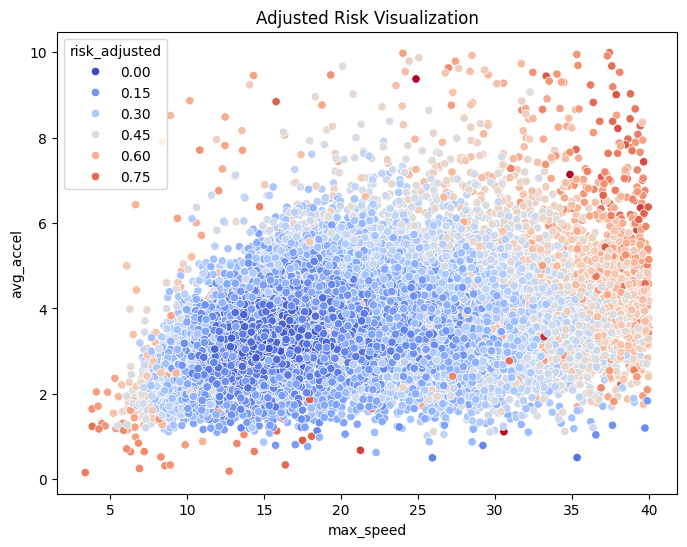


Top Risky Trips (Adjusted):
       avg_speed  max_speed  avg_accel  stop_rate  risk_adjusted
6242   20.192057  24.878464   9.372814        0.0       0.871262
39646  28.394739  34.877343   7.134638        0.0       0.870482
9887   28.408917  30.586588   1.109798        0.0       0.870248
3361   37.331209  39.762495   2.771282        0.0       0.842352
39076  31.519098  33.185902   3.333607        0.0       0.827107


In [13]:
# ====================== TOP RISKY ======================
print("\nTop Risky Trips (Adjusted):")
print(df.sort_values('risk_adjusted', ascending=False)[[
    'avg_speed','max_speed','avg_accel','stop_rate','risk_adjusted'
]].head())